In [57]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [58]:
path_to_csv = r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\car-sales-extended-missing-data.csv'

df = pd.read_csv(path_to_csv)

In [59]:
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [60]:
df.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Make           951 non-null    object 
 1   Colour         950 non-null    object 
 2   Odometer (KM)  950 non-null    float64
 3   Doors          950 non-null    float64
 4   Price          950 non-null    float64
dtypes: float64(3), object(2)
memory usage: 39.2+ KB


In [62]:
cols_num = ['Odometer (KM)', 'Price']
df[cols_num]

,Odometer (KM),Price
0,35431.0,15323.0
1,192714.0,19943.0
2,84714.0,28343.0
3,154365.0,13434.0
4,181577.0,14043.0
...,...,...
995,35820.0,32042.0
996,155144.0,5716.0
997,66604.0,31570.0
998,215883.0,4001.0


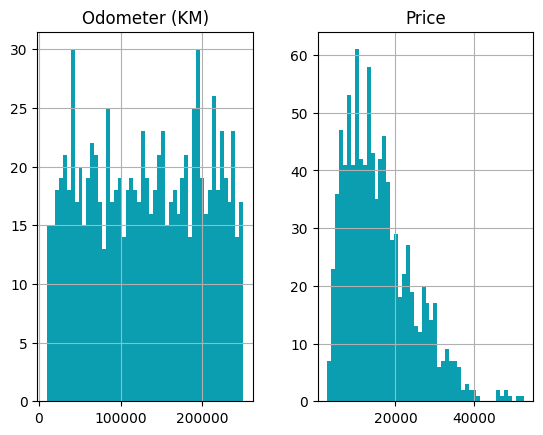

In [63]:
df[cols_num].hist(color="#0B9EB1", bins=50);

In [64]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(n_estimators=200, contamination=0.10)
pred = iso_f.fit_predict(df['Price'].to_frame())
mask = pred == -1

In [65]:
df[mask]

,Make,Colour,Odometer (KM),Doors,Price
16,Toyota,Red,96742.0,4.0,34465.0
55,BMW,White,79937.0,5.0,48686.0
69,BMW,White,37513.0,5.0,32379.0
86,Nissan,Blue,NaN,4.0,3300.0
89,NaN,Blue,90249.0,4.0,35988.0
...,...,...,...,...,...
993,Nissan,Black,162523.0,4.0,4696.0
994,BMW,Blue,163322.0,3.0,31666.0
995,Toyota,Black,35820.0,4.0,32042.0
997,Nissan,Blue,66604.0,4.0,31570.0


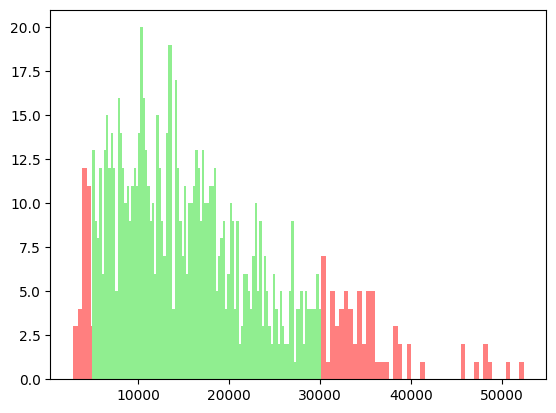

In [66]:
plt.hist(df.loc[mask, 'Price'], bins=100, color='#FF7F7F')
plt.hist(df.loc[~mask, 'Price'], bins=100, color='lightgreen')
plt.show()

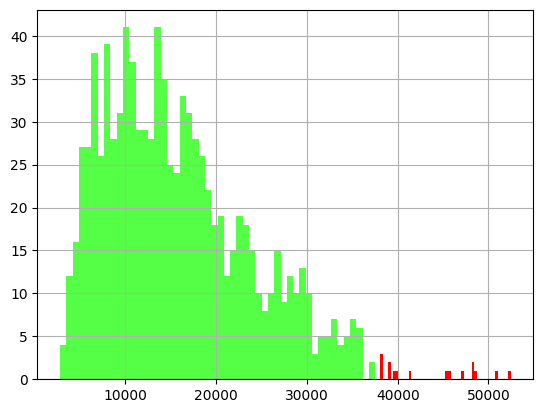

In [67]:
# m = df['Price'].median()
q1, m, q3 = df['Price'].quantile([0.25,0.5, 0.75])

iqr = np.abs(q1 - q3)
lower_limit = q1 - 1.5*iqr 
upper_limit = q3 + 1.5*iqr 

upper_outlier = df['Price'] > upper_limit
lower_outlier = df['Price'] < lower_limit

outlier_mask = upper_outlier | lower_outlier
df.loc[outlier_mask, 'Price'].hist(bins=50, color="#FF0000")
df.loc[~outlier_mask, 'Price'].hist(bins=50, color='#54ff45')
plt.show()

In [68]:
df2 = df.loc[~outlier_mask]

In [70]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder